# Phase 06 — Predictive Modelling & Interpretability

**Education and Income Inequality: A Cross-Country Panel Analysis**

This notebook closes the explanatory layer of the project by training
flexible tree-based machine-learning models (Random Forest, XGBoost) on
the same panel that Phase 05 used for econometric estimation, then
attributing predictions back to features via TreeSHAP. The analytical
question Phase 06 answers is:

> *Do flexible non-linear models tell the same story as the panel
> regressions, and where do they diverge?*

The deliverable is the comparison between Phase 05 RE Spec A
coefficient rankings and Phase 06 mean |SHAP| rankings, plus the
per-cluster mys-Gini slope mapping that connects to Phase 05's Cluster
1 (Kuznets-transition) finding.

**Convention 6.13 reminder.** Predictive performance is a means, not
the deliverable. A high test R² that merely re-derives the Phase 04
PC1 development gradient adds no portfolio information. The narrative
below foregrounds the comparison.

**Convention 6.15 reminder.** SHAP attribution is a feature-importance
decomposition over predictions, not a causal estimate. The Phase 05 RE
coefficient is also not causal. The Phase 05 vs Phase 06 comparison is
between two non-causal characterisations of the same data. Causal
framing is deferred to Phase 07.
    

## 1. Setup and data

The Phase 06 analytical sample is the Phase 05 Spec A listwise sample:
1,642 country-years across 153 countries, with `gini` and the five
Spec A right-hand-side variables non-null. The temporal split holds
out years 2019–2023 (test) and trains on 1990–2018, giving roughly an
80 / 20 split. The 13-feature specification adds eight covariates over
Spec A (sector trio, trade openness, government expenditure, inflation,
unemployment, plus Phase 04 cluster typology) which Phase 05 had to
drop on multicollinearity or transformation grounds; tree models
tolerate them all.
    

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "PROJECT_LOG.md").exists():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Could not find project root")
    PROJECT_ROOT = PROJECT_ROOT.parent
print("Project root:", PROJECT_ROOT)

TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
DATA = PROJECT_ROOT / "data" / "processed"

panel_ml = pd.read_csv(DATA / "panel_ml.csv")
print(f"panel_ml.csv shape: {panel_ml.shape}")
print(f"countries: {panel_ml['iso3'].nunique()}")
print(f"split distribution: {panel_ml['split'].value_counts().to_dict()}")
panel_ml.head(3)
    

Project root: c:\Users\kotae\Documents\Portfolio\project\Project 4\education-inequality-analysis
panel_ml.csv shape: (1642, 20)
countries: 153
split distribution: {'train': 1325, 'test': 317}


,iso3,country_name,year,region_name,income_level_name,gini,mean_years_schooling,enrol_secondary,log_gdp_per_capita_ppp,log_population,urban_population_pct,agri_value_added_gdp,manu_value_added_gdp,services_value_added_gdp,trade_openness,gov_expenditure_gdp,inflation_cpi,unemployment_rate,cluster_kmeans_k3,split
0,AGO,Angola,2000,Sub-Saharan Africa,Lower middle income,51.9,3.425746,13.369070,8.824149,16.600205,50.507065,NaN,NaN,NaN,NaN,NaN,324.996872,16.646,0.0,train
1,AGO,Angola,2008,Sub-Saharan Africa,Lower middle income,42.7,3.747596,22.799021,9.317822,16.887215,58.585175,7.818318,3.532351,34.221294,108.680409,18.201028,12.475829,16.152,0.0,train
2,ALB,Albania,1996,Europe & Central Asia,Upper middle income,27.0,7.623845,68.990097,8.624035,14.968621,38.899604,33.561661,5.554144,39.466360,44.411782,9.599403,12.725478,13.928,1.0,train


**Observation.** 1,642 country-years across 153 countries; train
(year ≤ 2018) holds 1,325 rows, test (2019–2023) holds 317 rows. The
cluster column has 37 NaN rows corresponding to Phase 04 listwise-drop
countries that survived into the Spec A sample.

**Explanation.** This row set is locked at Phase 05 Spec A's sample so
the SHAP-vs-coefficient comparison runs on the same identification
window. Tree models do not require scaling or imputation; the panel is
fed essentially as-is. Per Decision 5, XGBoost preserves NaN natively;
Random Forest receives a −1 sentinel for unclustered countries and
median-imputes missing extended-feature cells; the Ridge baseline gets
median imputation plus standardisation plus a four-way one-hot
cluster encoding (cluster_0 / 1 / 2 / unclustered).

**Implication.** The 50-country MNAR exclusion that defined Phase 04's
listwise sample applies here too: the predictive results below
characterise the sub-population of 153 countries that report Gini at
least once between 1990 and 2023, not all 217 World Bank countries.
    

## 2. Modelling strategy

Three models, fit on the same train block, evaluated on the same test
block:

- **Ridge** (linear baseline, α tuned by `RidgeCV` over a
  log-spaced grid of 13 values from 1e-3 to 1e+3)
- **Random Forest** (`sklearn.ensemble.RandomForestRegressor`,
  hyperparameters tuned by `RandomizedSearchCV` over a 432-cell
  pre-registered grid)
- **XGBoost** (`xgboost.XGBRegressor`,
  hyperparameters tuned by `RandomizedSearchCV` over a 5,184-cell
  pre-registered grid)

All hyperparameter searches use `TimeSeriesSplit(n_splits=5)` over the
year-sorted training block, enforcing temporal monotonicity within the
search itself (Convention 6.14). `random_state=42` throughout.
Random K-fold metrics are reported alongside as a leakage diagnostic
(Convention 6.7).
    

## 3. Predictive performance

### 3.1 Headline metrics

The `phase06_s03_*`, `phase06_s04_*`, `phase06_s05_*` results CSVs
each carry the same set of metrics in long format. Below the
test-block RMSE, MAE, R², and the TSS / random-KFold cross-validation
RMSE comparison are pulled out of those long tables and pivoted.
    

In [2]:
import pandas as pd

ridge_long = pd.read_csv(TABLES / "phase06_s03_linear_baseline.csv")
rf_long = pd.read_csv(TABLES / "phase06_s04_rf_results.csv")
xgb_long = pd.read_csv(TABLES / "phase06_s05_xgb_results.csv")

def extract(long_df, model_name):
    out = {}
    for metric in ("rmse", "mae", "r2"):
        for split in ("train", "test"):
            row = long_df[(long_df["metric"] == metric) & (long_df["split"] == split)]
            if len(row) == 1:
                out[f"{split}_{metric}"] = float(row["value"].values[0])
    for metric in ("tss_cv_rmse_best", "rkf_cv_rmse_mean"):
        row = long_df[long_df["metric"] == metric]
        if len(row) == 1:
            out[metric] = float(row["value"].values[0])
    out["model"] = model_name
    return out

summary = pd.DataFrame([
    extract(ridge_long, "Ridge"),
    extract(rf_long, "Random Forest"),
    extract(xgb_long, "XGBoost"),
]).set_index("model")

# Add a TSS - RKF gap column
summary["tss_minus_rkf_rmse"] = (summary["tss_cv_rmse_best"]
                                 - summary["rkf_cv_rmse_mean"])

cols_order = [
    "train_rmse", "test_rmse", "train_r2", "test_r2",
    "tss_cv_rmse_best", "rkf_cv_rmse_mean", "tss_minus_rkf_rmse",
]
summary[cols_order].round(3)
    

,train_rmse,test_rmse,train_r2,test_r2,tss_cv_rmse_best,rkf_cv_rmse_mean,tss_minus_rkf_rmse
model,,,,,,,
Ridge,5.871,4.969,0.524,0.426,5.906,6.016,-0.110
Random Forest,1.247,3.554,0.979,0.706,3.941,3.532,0.409
XGBoost,0.310,3.387,0.999,0.733,3.941,3.345,0.595


**Observation.** Test R² climbs from 0.43 (Ridge) to 0.71 (RF) to
0.73 (XGBoost). The TSS minus RKF RMSE gap rises in tandem: −0.11
(Ridge), +0.41 (RF), +0.60 (XGBoost).

**Explanation.** Two patterns sit on top of each other. First, model
flexibility buys real predictive value: the Ridge → RF jump (+0.28
test R²) is the non-linear and interaction-driven signal that Phase 05
linear panel models could not capture. Second, the TSS-minus-RKF gap
widening with model flexibility is *not* an overfitting bug; it is the
**temporal extrapolation cost** intrinsic to panel data. RF and
XGBoost have train R² above 0.97, but the cost of extrapolating from
1990–2018 to 2019–2023 erodes that into 0.71–0.73 on test. Random
K-fold within the train block reaches 3.5 RMSE because random folds
mix nearby years; temporal folds do not.

**Implication.** Phase 06 portfolio narrative should treat the
0.71 / 0.73 test R² as *internal-extrapolation* performance on a
sample defined by Gini-reporting countries. Step 8.2 below shows what
happens when the sample is broken in a different way (boundary-case
country holdout) — the picture changes drastically.
    

## 4. SHAP global attribution

TreeSHAP is computed on the test-set predictions of both tree models.
The summary beeswarm plots below show, for each feature: the SHAP-value
distribution (x-axis), coloured by feature value (red = high, blue =
low). A negative SHAP pushes the predicted Gini *down*; for
`mean_years_schooling`, the dominant pattern is high-mys / negative
SHAP (red dots on the left), which is the SHAP analogue of the Phase
05 negative coefficient sign.
    

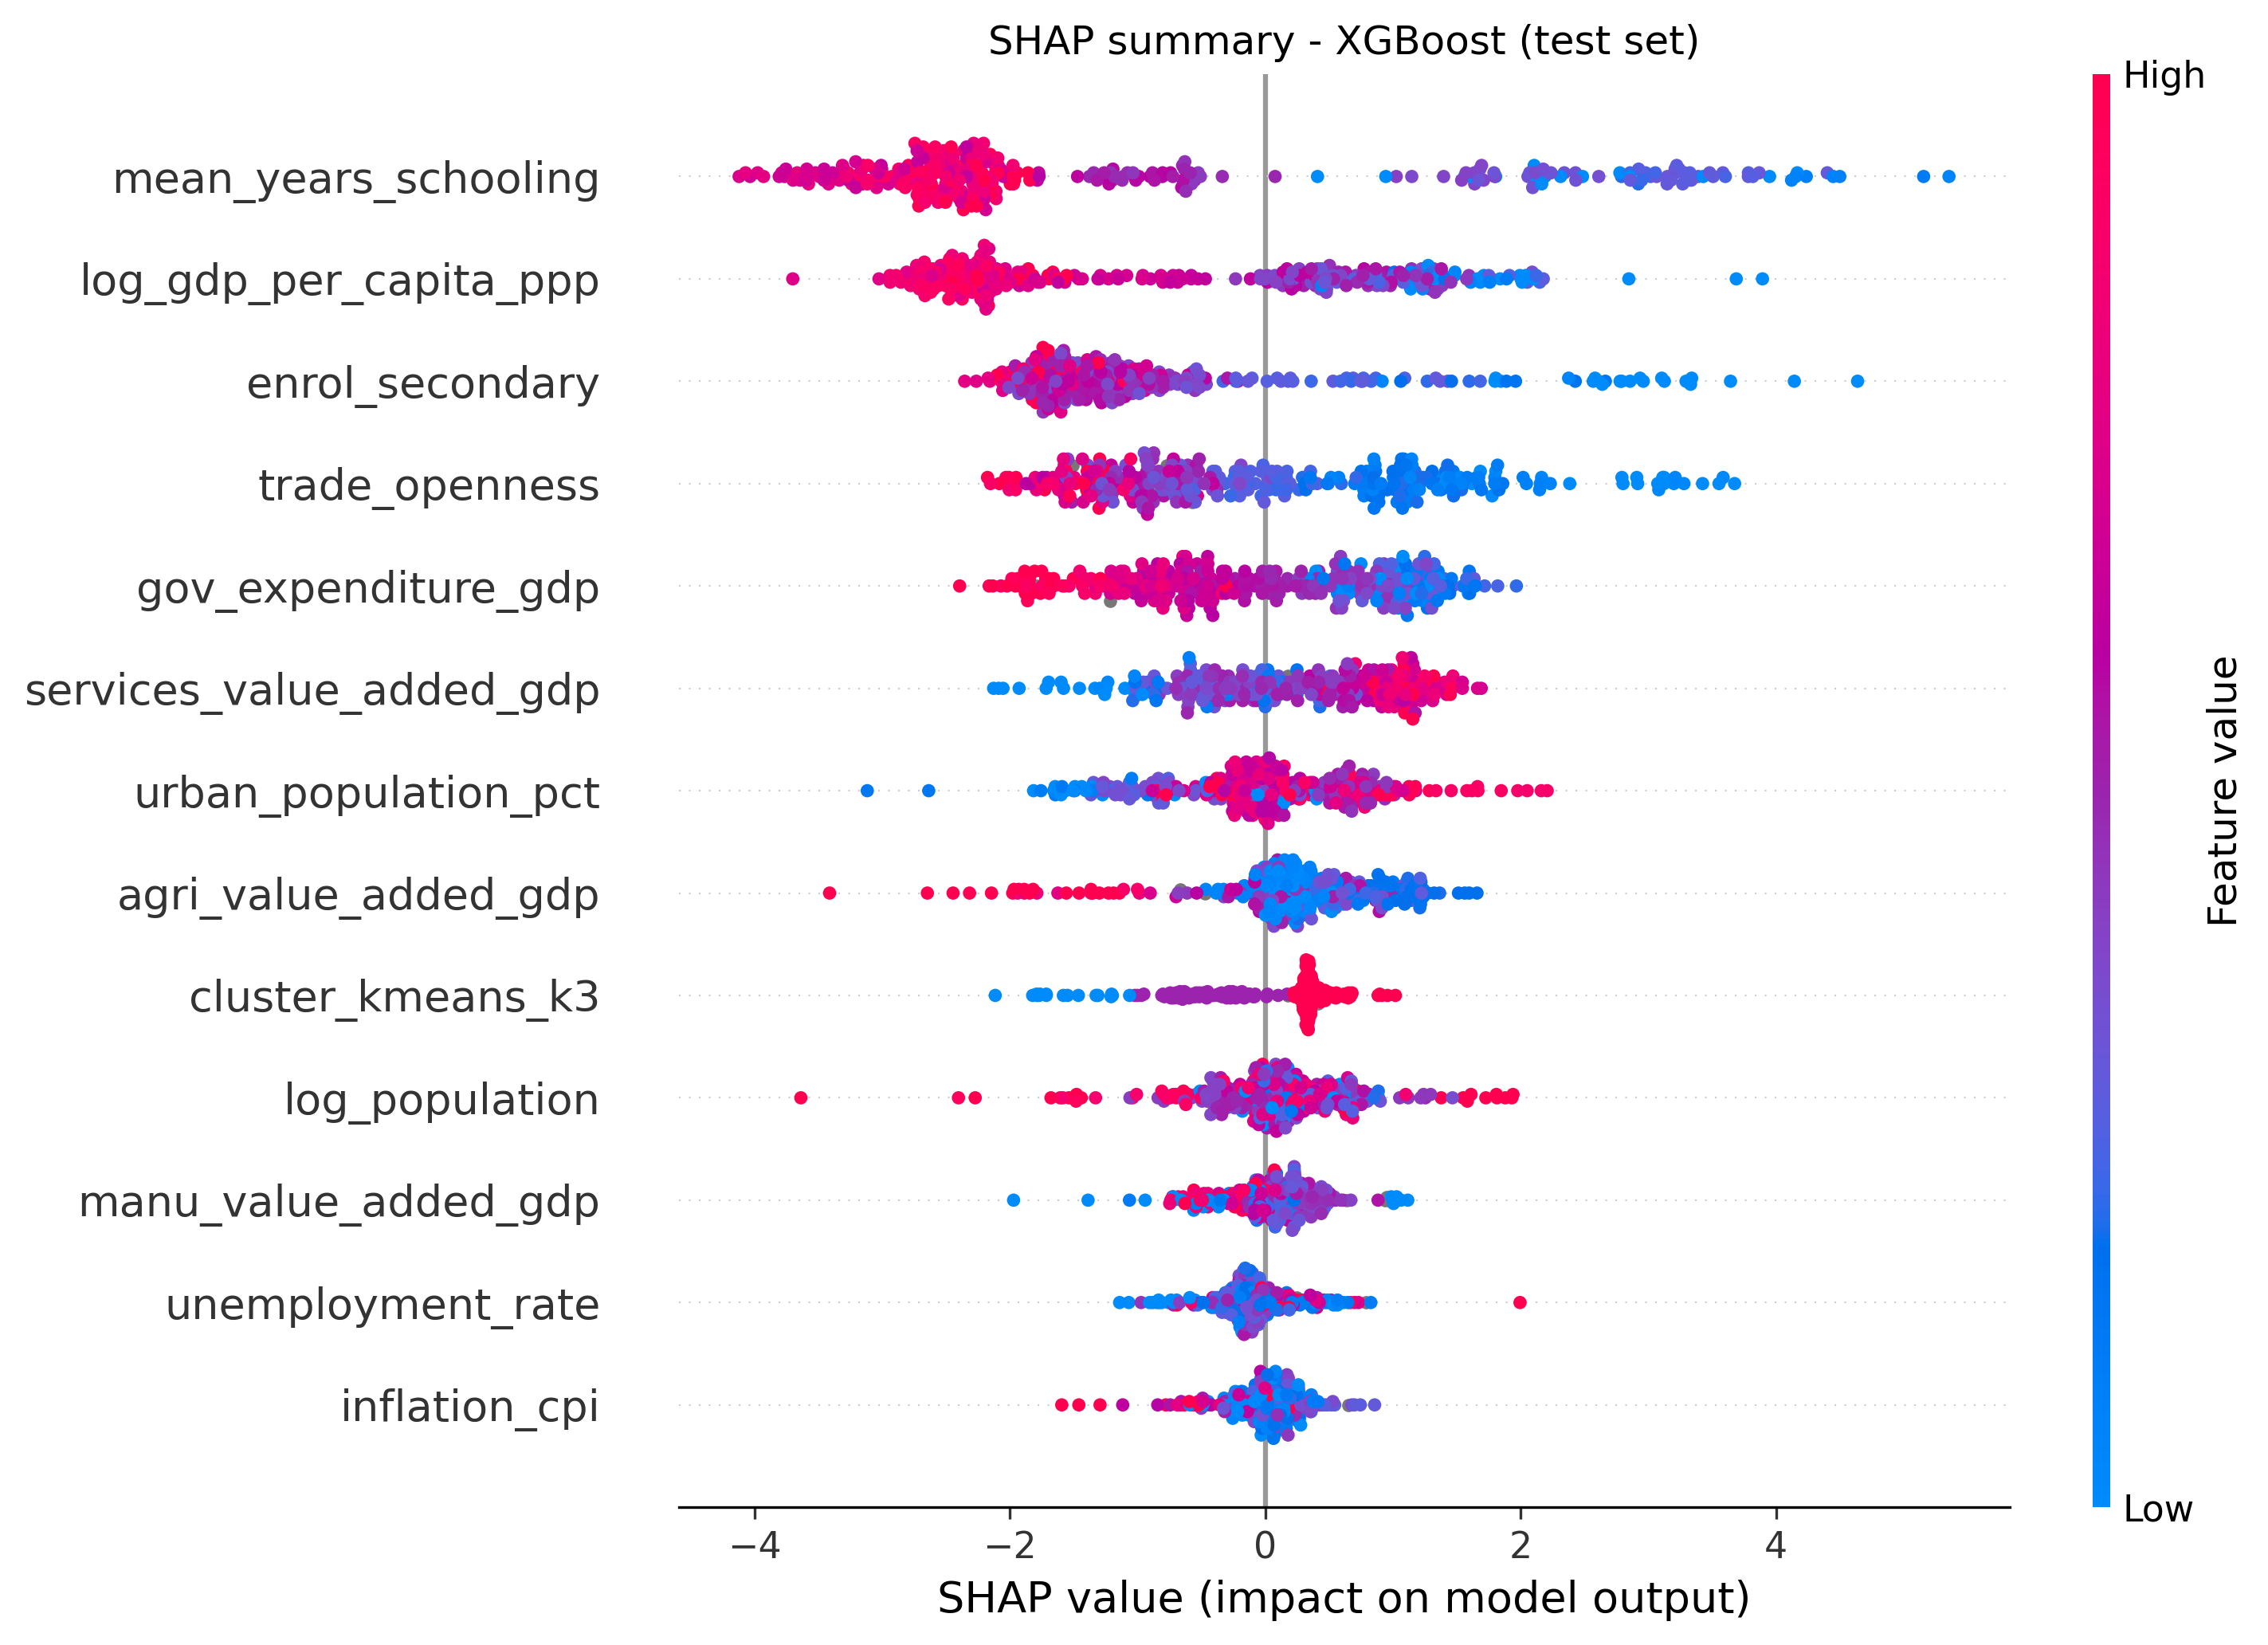

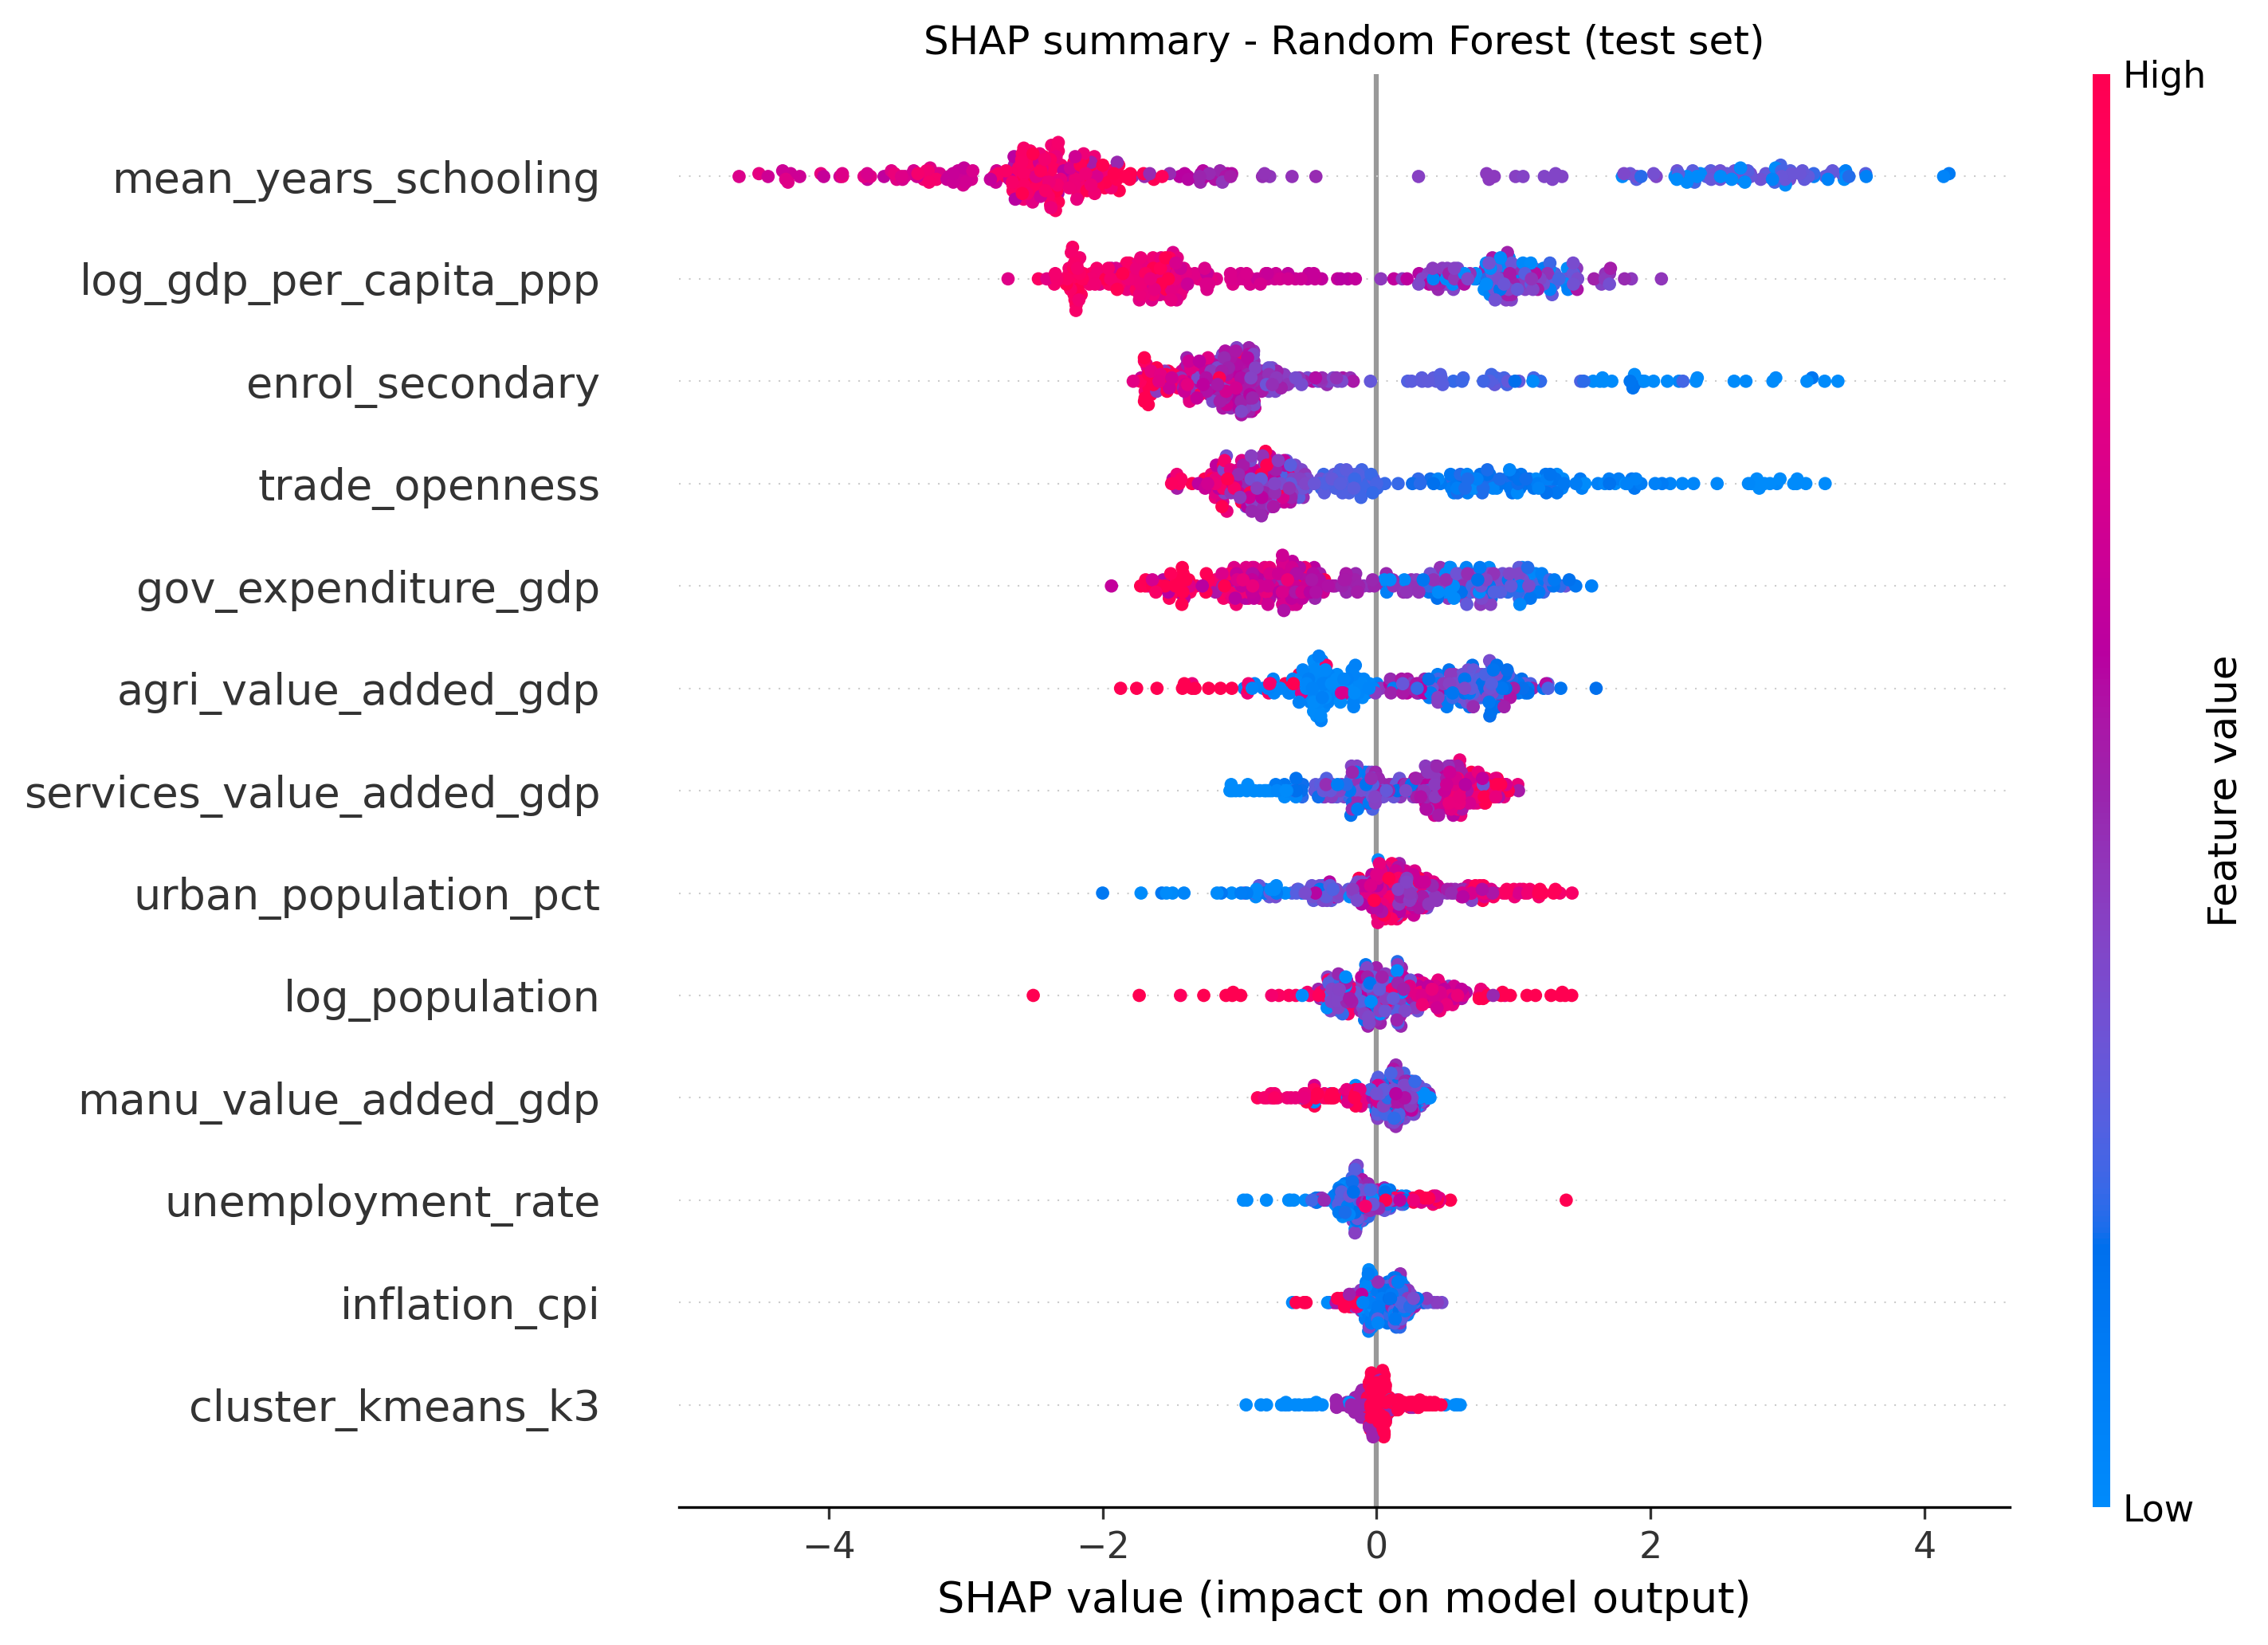

In [3]:
display(Image(filename=str(FIGURES / "phase06_s06_shap_summary_xgb.png")))
display(Image(filename=str(FIGURES / "phase06_s06_shap_summary_rf.png")))
    

In [4]:
shap_global = pd.read_csv(TABLES / "phase06_s06_shap_global.csv")
pivot = (
    shap_global.pivot_table(index=["rank"], columns="model",
                            values=["feature", "mean_abs_shap", "mean_signed_shap"],
                            aggfunc="first")
    .reorder_levels([1, 0], axis=1)
    .sort_index()
)
# Friendlier display
out = shap_global.pivot_table(
    index="feature", columns="model",
    values=["rank", "mean_abs_shap", "mean_signed_shap"],
).round(4)
out
    

mean_abs_shap         mean_signed_shap          rank  \
model                               rf     xgb               rf     xgb    rf   
feature                                                                         
agri_value_added_gdp            0.5915  0.5776           0.1440  0.2207   6.0   
cluster_kmeans_k3               0.1259  0.4716          -0.0090  0.0056  13.0   
enrol_secondary                 1.1627  1.4352          -0.6495 -0.8576   3.0   
gov_expenditure_gdp             0.8191  0.9187          -0.1415 -0.0152   5.0   
inflation_cpi                   0.1324  0.1982           0.0416  0.0033  12.0   
log_gdp_per_capita_ppp          1.3130  1.6064          -0.4667 -0.7184   2.0   
log_population                  0.3082  0.4480           0.0683  0.1026   9.0   
manu_value_added_gdp            0.1999  0.2830           0.0353  0.0524  10.0   
mean_years_schooling            2.4758  2.4806          -1.1298 -1.0599   1.0   
services_value_added_gdp        0.4514  0.6998           0.2001  0.2012   7.0   
trade_openness                  0.9579  1.1248           0.0242  0.0016   4.0   
unemployment_rate               0.1846  0.2429          -0.0812 -0.0905  11.0   
urban_population_pct            0.3889  0.5969           0.0933 -0.0186   8.0   

                                
model                      xgb  
feature                         
agri_value_added_gdp       8.0  
cluster_kmeans_k3          9.0  
enrol_secondary            3.0  
gov_expenditure_gdp        5.0  
inflation_cpi             13.0  
log_gdp_per_capita_ppp     2.0  
log_population            10.0  
manu_value_added_gdp      11.0  
mean_years_schooling       1.0  
services_value_added_gdp   6.0  
trade_openness             4.0  
unemployment_rate         12.0  
urban_population_pct       7.0

**Observation.** The two tree models converge on the same global
ranking: `mean_years_schooling` #1, `log_gdp_per_capita_ppp` #2,
`enrol_secondary` #3, `trade_openness` #4, `gov_expenditure_gdp` #5
on both. Mean signed SHAP for mys is approximately −1.13 (RF) and
−1.06 (XGBoost) per country-year.

**Explanation.** The complete top-5 agreement across two
algorithmically dissimilar models means the SHAP attribution is a
property of the data, not a quirk of one model. The rank-1 finding
for `mys` extends the chain that runs from Phase 03's Pearson
r = −0.52, through Phase 03's univariate OLS R² = 0.27, through Phase
05's Pooled OLS coefficient of −1.328 and RE coefficient of −0.69,
into the non-linear regime. The mys signed SHAP magnitudes (~−1.1)
sit close to Pooled OLS / Ridge anchors and well above FE / RE,
indicating that ML — like Pooled OLS — is performing a mixed
between-and-within-country identification.

**Implication.** The Phase 04 PC1 = 63.2% one-dimensional development
gradient is reproduced here in a third independent way. Phase 06's
genuine novelty (the 'beyond PC1' contribution per Convention 6.13)
must therefore live in the *per-cluster slopes* and *dependence-plot
shapes*, not in the global ranking.
    

### 4.1 Where impurity / gain importance disagrees with SHAP

`cluster_kmeans_k3` ranks #2 in XGBoost gain-based importance (≈0.20,
nearly tied with mys), but #9 in mean |SHAP| (≈0.47). In Random
Forest, the cluster column ranks #13 in impurity-based importance
(≈0.02) but #13 in mean |SHAP| (≈0.13) — agreement at the low end.
The XGBoost discrepancy reflects the well-documented bias of
gain-based importance: low-cardinality categorical features get used
as cheap first-cut splits regardless of their marginal contribution
to predictions. SHAP corrects for this. Reviewers should not trust
gain importance alone.
    

## 5. SHAP per-cluster

Per-cluster aggregation splits the test-set SHAP attributions by
Phase 04 K-means cluster ID (0 = low-development / SSA-led, 1 =
middle-development / Kuznets transition, 2 = mature economies).
Mean |SHAP| measures how much the feature moves predictions in
absolute terms; mean signed SHAP measures the direction of net
attribution within the cluster.
    

In [5]:
shap_pc = pd.read_csv(TABLES / "phase06_s06_shap_per_cluster.csv")
mys_pc = (
    shap_pc[shap_pc["feature"] == "mean_years_schooling"]
    .pivot_table(index="cluster", columns="model",
                 values=["mean_abs_shap", "mean_signed_shap", "n"])
    .round(4)
)
mys_pc
    

mean_abs_shap         mean_signed_shap              n       
model              rf     xgb               rf     xgb     rf    xgb
cluster                                                             
0              2.4522  2.2762           2.4522  2.2762   17.0   17.0
1              2.7687  2.7667          -0.3922 -0.0030  105.0  105.0
2              2.3168  2.3498          -1.8631 -1.9505  188.0  188.0
all            2.4758  2.4806          -1.1298 -1.0599  317.0  317.0

**Observation.** Mean |SHAP| of mys is essentially flat across
clusters (~2.4 absolute), but mean *signed* SHAP varies dramatically:
+2.3 to +2.5 for Cluster 0, near zero (RF: −0.39, XGB: 0.00) for
Cluster 1, −1.86 to −1.95 for Cluster 2.

**Explanation.** Signed mean SHAP is a *level* effect: it answers
'where does this cluster's typical mys value sit relative to the
training mean, and what does the model predict it does to Gini?'.
Cluster 0 has low average mys (≈4.2 years), well below the global
mean, so the model predicts mys is pushing their Gini up relative to
base. Cluster 2 is the mirror image (≈11.4 years, Gini pushed down).
Cluster 1 sits near the training mean, so the level signal is small
even though *within-cluster* variation in mys may be highly predictive
(see Step 7 slope analysis).

**Implication.** Mean signed SHAP is **not** the SHAP analogue of a
Phase 05 within-cluster panel coefficient. To compare like with like,
the next section regresses SHAP_mys on mys within each cluster
(slope-of-SHAP), which extracts the local marginal effect rather than
the cluster-aggregate level shift.
    

## 6. Phase 05 vs Phase 06 comparison

Three axes of comparison:

1. Spearman ρ between Phase 05 RE Spec A absolute coefficient ranking
   and Phase 06 mean |SHAP| ranking on the five common features.
2. Per-cluster mys slope: Phase 05 RE Spec C within-cluster
   coefficient vs Phase 06 SHAP-on-mys regression slope.
3. Qualitative shape of the mys SHAP dependence plot — non-linearity
   beyond Phase 05's linear specification.
    

### 6.1 Global ranking — Spearman ρ
    

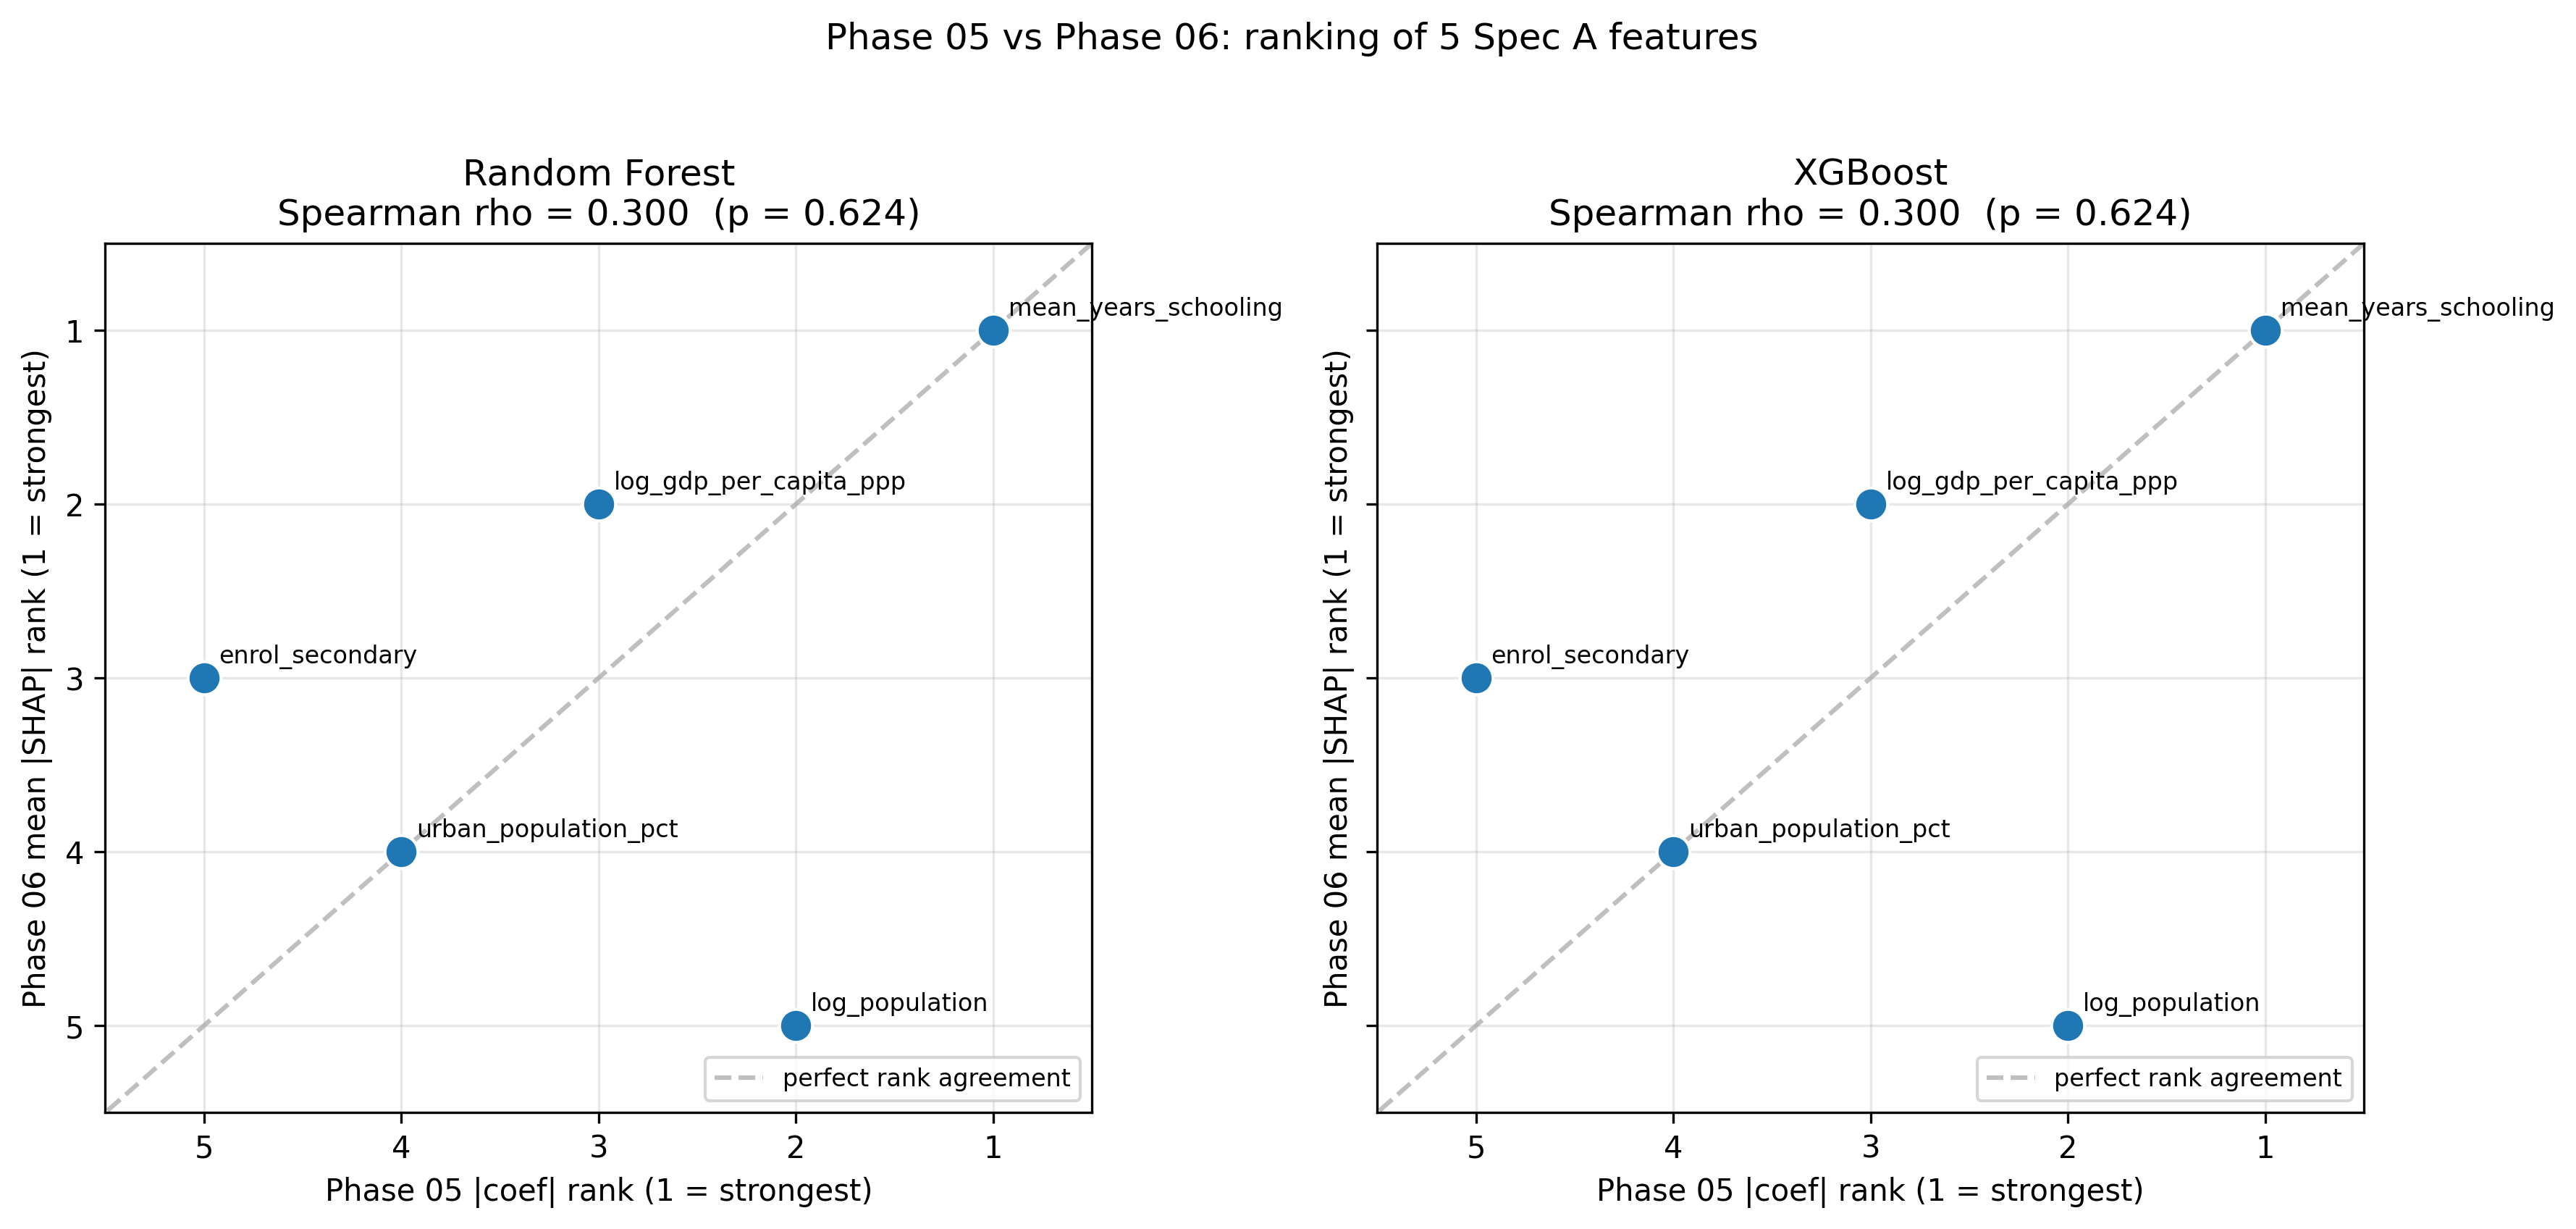

,model,spearman_rho,p_value,n
0,rf,0.3,0.623838,5.0
1,xgb,0.3,0.623838,5.0


In [6]:
display(Image(filename=str(FIGURES / "phase06_s07_ranking_comparison.png")))

cmp = pd.read_csv(TABLES / "phase06_s07_comparison.csv")
spearman = cmp[cmp["axis"] == "ranking_spearman"][[
    "model", "metric_value", "metric_pvalue", "n",
]].rename(columns={"metric_value": "spearman_rho",
                   "metric_pvalue": "p_value"}).reset_index(drop=True)
spearman
    

**Observation.** Spearman ρ = +0.30 for both Random Forest and
XGBoost (n = 5, p = 0.624). `mean_years_schooling` ranks #1 in both
phases. `log_population` is Phase 05 #2 and Phase 06 #5 — the largest
disagreement.

**Explanation.** A naïve reading is 'weak agreement'. The careful
reading: of the five Spec A coefficients in Phase 05 RE, only mys is
statistically significant (p = 0.016); the other four have p-values
between 0.19 and 0.95. The Phase 05 |coef| ranking after #1 is therefore
sorting noise. The +0.30 Spearman should be read as 'mys is robust
top, the rest is unstable on both sides' — not as a Phase 05–Phase 06
divergence.

**Implication.** Treat Phase 06 mys #1 and the broad agreement on the
top of the list as the robust story. The bottom of the list is
unreliable from either method on this sample size.
    

### 6.2 Per-cluster mys slope — the headline result

The Phase 05 Cluster 1 finding (RE Spec C within-cluster slope =
−1.19, p = 0.010) is the most-cited Phase 05 number. The chart below
puts that bar next to the Phase 06 SHAP-on-mys regression slope for
each cluster, computed from the test-set SHAP values.
    

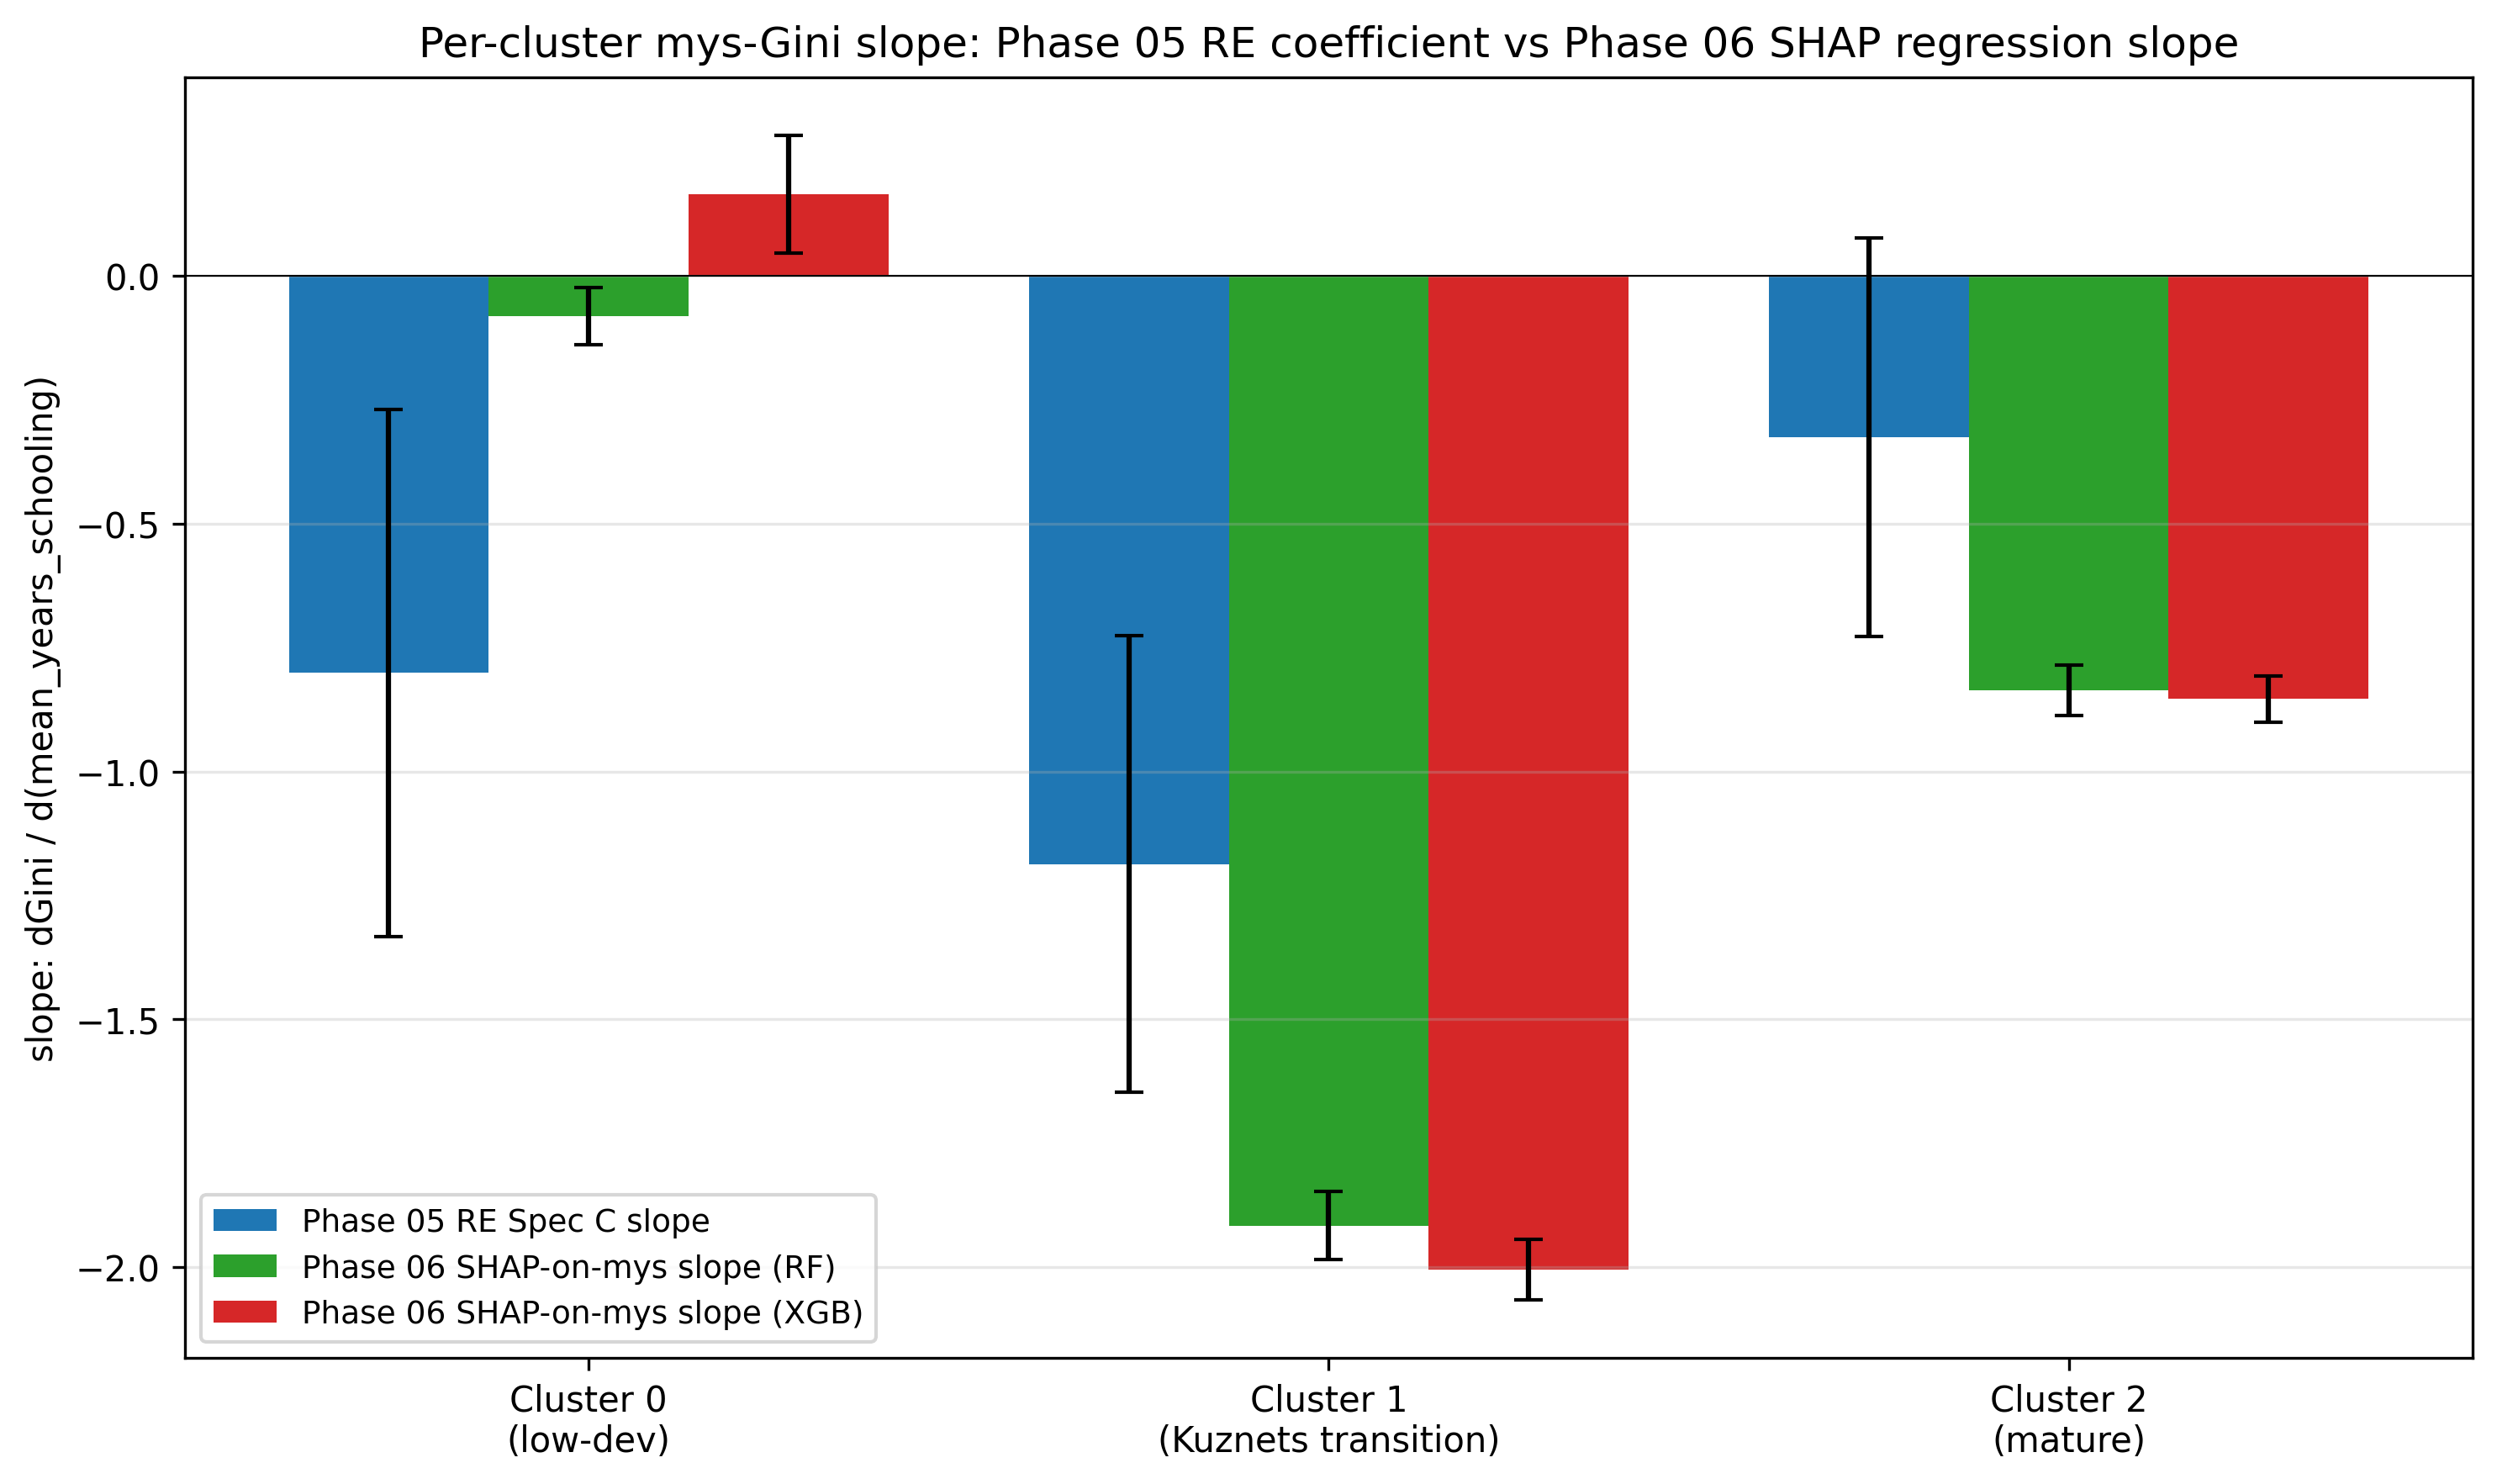

,model,cluster,phase05_value,phase06_value,p06_minus_p05_slope,n,sign_agreement
0,rf,cluster_0,RE slope=-0.8009 (p=0.1325),SHAP-on-mys slope=-0.0814 (p=0.1755),0.719443,17.0,True
1,xgb,cluster_0,RE slope=-0.8009 (p=0.1325),SHAP-on-mys slope=+0.1644 (p=0.1855),0.965296,17.0,False
2,rf,cluster_1,RE slope=-1.1865 (p=0.0101),SHAP-on-mys slope=-1.9159 (p=0.0000),-0.729358,105.0,True
3,xgb,cluster_1,RE slope=-1.1865 (p=0.0101),SHAP-on-mys slope=-2.0044 (p=0.0000),-0.817892,105.0,True
4,rf,cluster_2,RE slope=-0.3252 (p=0.4183),SHAP-on-mys slope=-0.8353 (p=0.0000),-0.510191,188.0,True
5,xgb,cluster_2,RE slope=-0.3252 (p=0.4183),SHAP-on-mys slope=-0.8534 (p=0.0000),-0.528262,188.0,True


In [7]:
display(Image(filename=str(FIGURES / "phase06_s07_per_cluster_slopes.png")))

slope_rows = cmp[cmp["axis"] == "per_cluster_mys_slope"][[
    "model", "feature_or_cluster", "phase05_value", "phase06_value",
    "metric_value", "n", "sign_agreement",
]].rename(columns={"feature_or_cluster": "cluster",
                   "metric_value": "p06_minus_p05_slope"}).reset_index(drop=True)
slope_rows
    

**Observation.** Sign agreement holds in 5 of 6 cluster × model
combinations (Phase 05 c0 = −0.80 ns vs Phase 06 c0 RF = −0.08 / XGB
= +0.16 — only XGB c0 disagrees, on n = 17 small subsample). For
Cluster 1 (Kuznets transition), Phase 05 RE slope = −1.19**, Phase 06
SHAP-on-mys slope = −1.92 (RF) and −2.00 (XGB) — both ML estimates
are stronger negative than the panel coefficient. For Cluster 2,
Phase 05 = −0.33 ns, Phase 06 = −0.84 / −0.85 — again ML stronger.

**Explanation.** Phase 06 corroborates the Phase 05 Cluster 1
heterogeneity finding via an independent estimation philosophy.
Beyond corroboration, Phase 06 estimates that within the
Kuznets-transition cluster the marginal effect of an extra year of
schooling on Gini is roughly 1.7 times what Phase 05's linear panel
RE captured. The same direction-strengthening pattern appears in
Cluster 2, where Phase 05 found no significant within-country slope
but ML detects a meaningful negative relationship — suggesting Phase
05's linear specification under-fits the mature-economy regime.
Cluster 0 is too small (test n = 17) to draw conclusions either way.

**Implication.** This is Phase 06's headline contribution. The Phase
05 Cluster 1 Kuznets finding survives a non-linear tree-based
estimator and intensifies under it. The 'beyond PC1' content per
Convention 6.13 sits here: ML detects within-cluster non-linearity
that Phase 05's RE Spec C linear-interaction term cannot fully
capture.
    

### 6.3 Dependence-plot shape

The dependence plot for mean_years_schooling, top panel below, is the
clearest qualitative evidence of where ML adds information beyond the
linear specification.
    

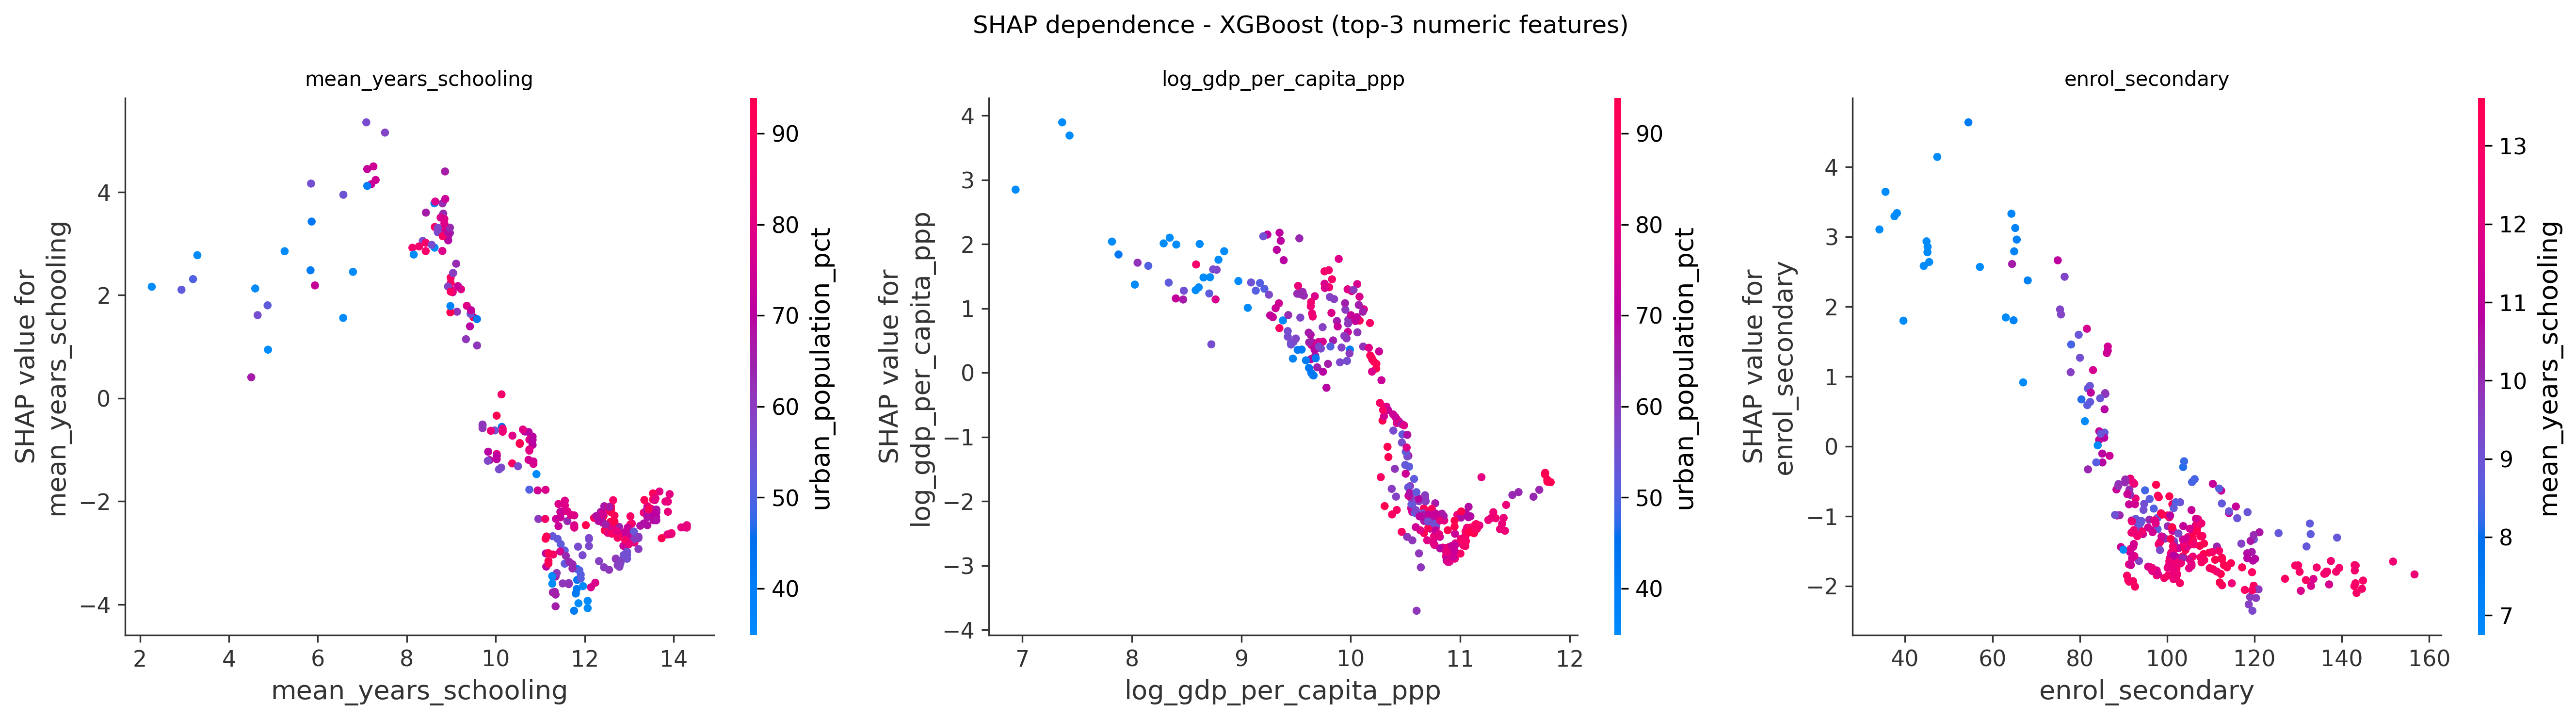

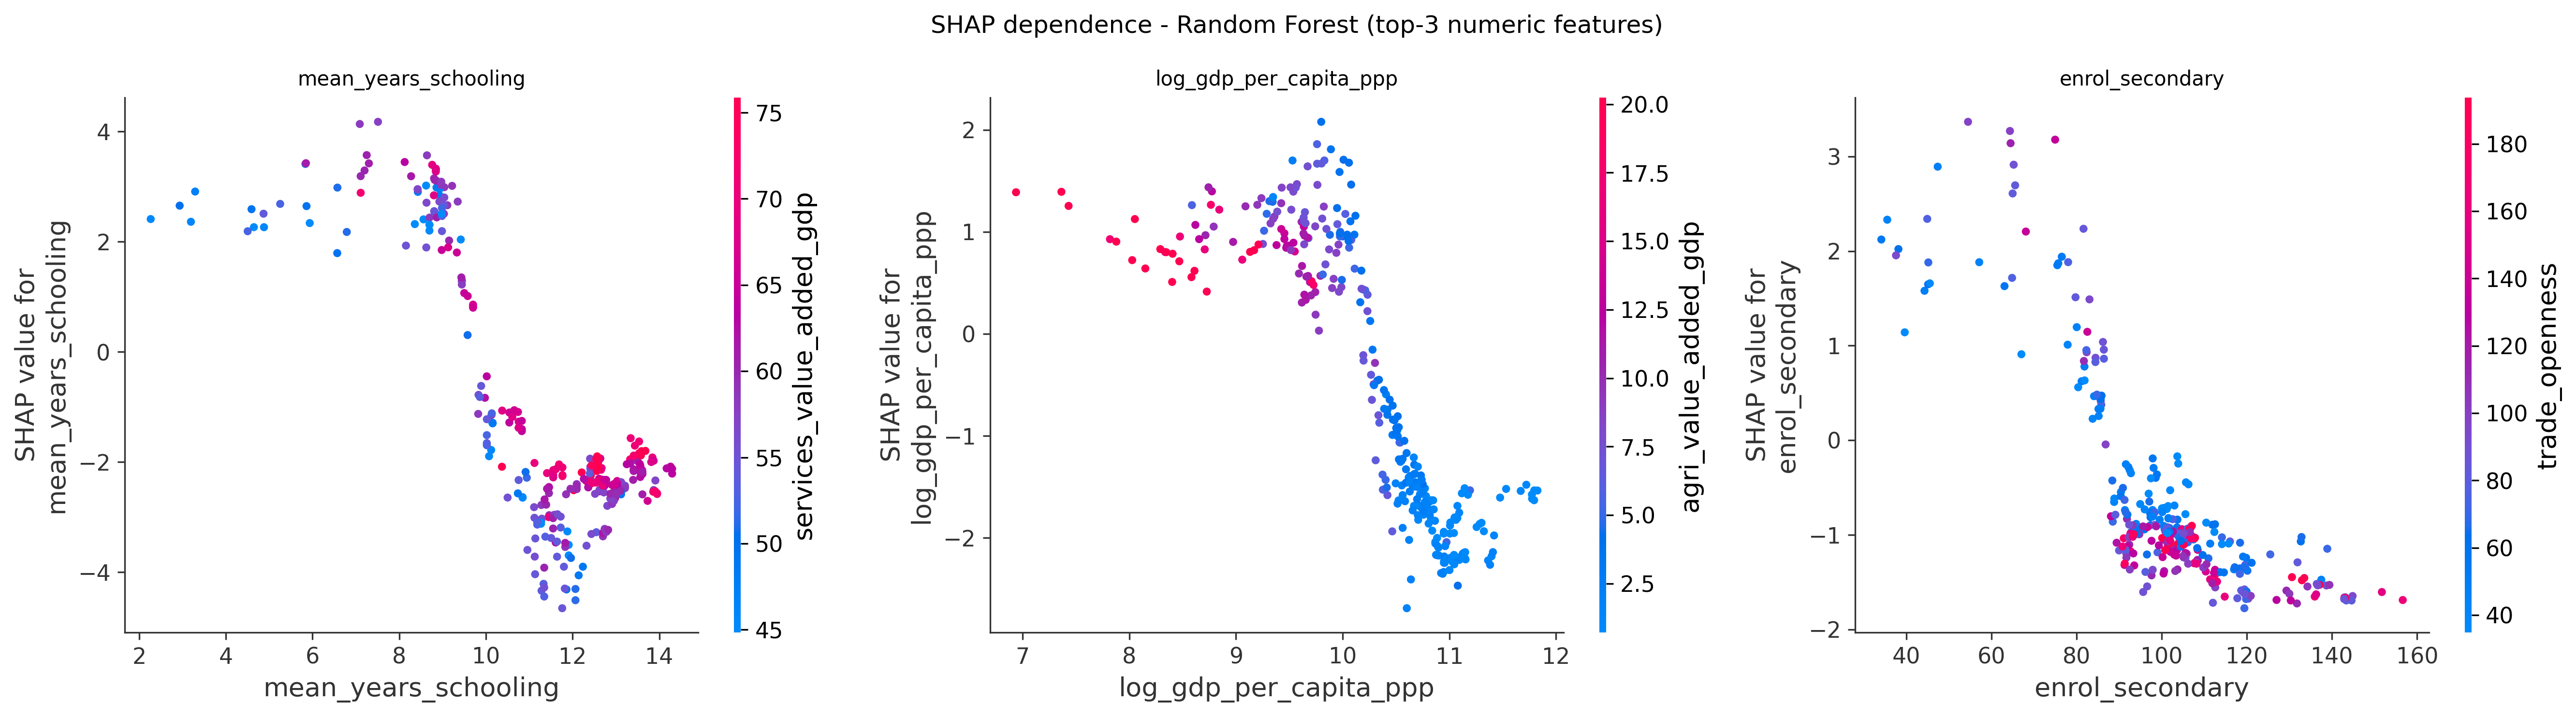

In [8]:
display(Image(filename=str(FIGURES / "phase06_s06_dependence_top3_xgb.png")))
display(Image(filename=str(FIGURES / "phase06_s06_dependence_top3_rf.png")))
    

**Observation.** SHAP_mys versus mys is broadly monotonically
decreasing in both models, but the slope is visibly *steeper* in the
mid-range (mys ≈ 6–10 years) than at the tails. Below ~5 years SHAP_mys
is high and roughly flat; above ~12 years SHAP_mys is sharply negative
but flattens.

**Explanation.** A Phase 05 linear specification would estimate a
single slope. The dependence plot shows the slope is itself a function
of mys — strongest exactly in the cluster-1 range. This is the
underlying mechanism behind the Phase 06 per-cluster slope finding in
6.2: ML splits the data along mys and finds the strongest local effect
in the Kuznets-transition range, which Phase 05's linear-interaction
specification can only approximate.

**Implication.** A non-linear functional form — splines, threshold
models, or panel quantile regression — is the natural next step
inside the linear-modelling family if one wanted to encode this
finding without leaving the panel framework. Phase 07 will discuss
identification rather than functional form, but flagging this is
useful for any extension work.
    

## 7. Local explanation — Brazil 2015

Brazil sits at the K-means / Ward boundary between Cluster 1 and
Cluster 2 in Phase 04, and is one of four boundary-case anchors in
Phase 05's robustness check. Brazil 2015 is in the train block, so
the XGBoost SHAP waterfall below is an in-sample explanation of the
model's prediction on a country-year that the model has effectively
seen (caveat).
    

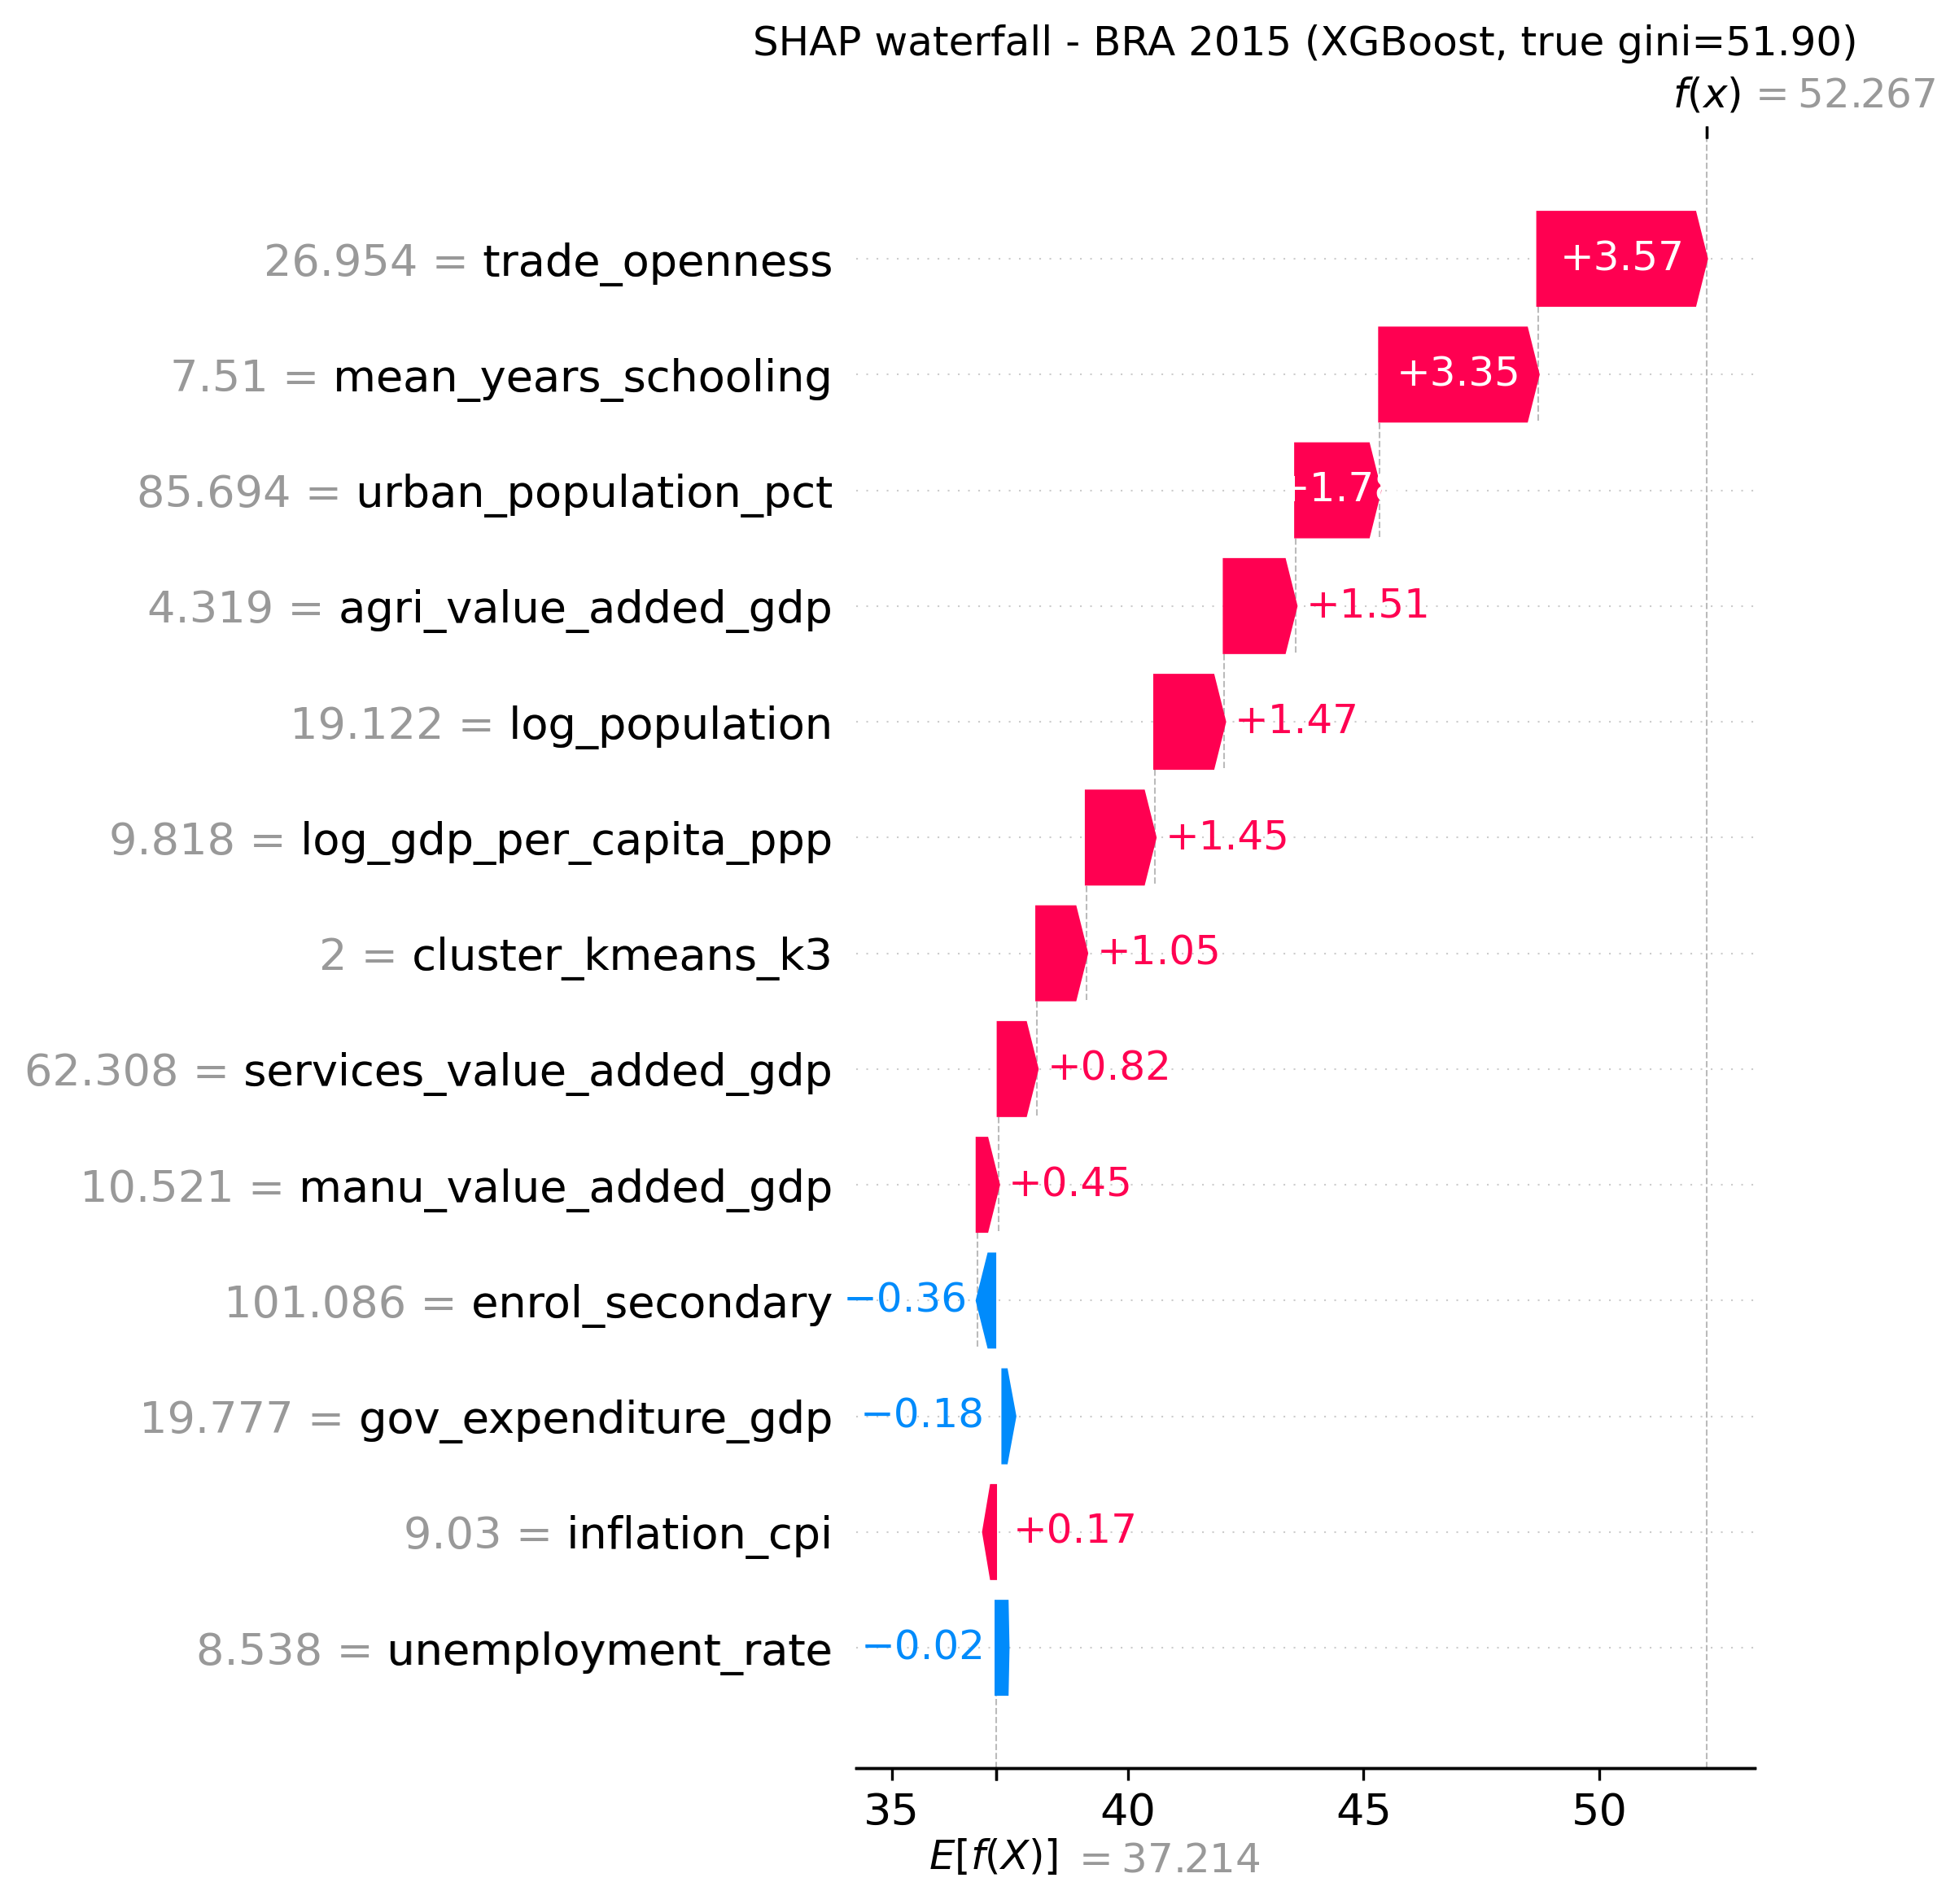

In [9]:
display(Image(filename=str(FIGURES / "phase06_s06_brazil2015_waterfall.png")))
    

**Observation.** Brazil 2015's predicted Gini is ~9 points above the
training-set base value (~37). The SHAP decomposition attributes this
gap mainly to high `mean_years_schooling`, low `agri_value_added_gdp`,
high `log_gdp_per_capita_ppp`, and high `gov_expenditure_gdp`.

**Explanation.** Brazil 2015's actual Gini was 51.9, a level driven
by historical inequality patterns that survive into the present
despite economic catching-up — the country has high income and rising
education yet inequality much higher than peers in Cluster 2. The
model partially captures this through positive contributions from the
income / education indicators (the model 'knows' Brazil-like profiles
have elevated Gini), but the residual is still substantial,
indicating Brazil-specific factors (Phase 04 boundary status, regional
heterogeneity within country) the model does not see.

**Implication.** Single-row SHAP explanations are useful for
sanity-checking the model's local reasoning but cannot validate it
causally. The waterfall illustrates which features the model leaned
on for this prediction; it does not say those features cause Brazil's
Gini to be 51.9.
    

## 8. Robustness

Two pre-registered checks: feature-set sensitivity and boundary-case
country holdout.
    

### 8.1 Feature-set sensitivity (Spec A only)

Refitting RF and XGBoost on the five Spec A features only (no
extended covariates, no cluster column), with the same temporal
split.
    

In [10]:
rob = pd.read_csv(TABLES / "phase06_s08_robustness.csv")

spec_a = rob[rob["check"] == "feature_set"]
test_metrics = spec_a[spec_a["metric"].str.startswith("test_")][[
    "model", "metric", "value",
]].pivot(index="model", columns="metric", values="value").round(4)
test_metrics
    

metric,test_mae,test_n,test_r2,test_rmse
model,,,,
rf,2.8655,317.0,0.6278,4.0021
xgb,2.7410,317.0,0.6638,3.8038


In [11]:
mys_rank_spec_a = spec_a[
    (spec_a["feature"] == "mean_years_schooling")
    & (spec_a["metric"].isin(["mean_abs_shap", "shap_rank"]))
][["model", "metric", "value"]].pivot(index="model", columns="metric", values="value")
mys_rank_spec_a
    

metric,mean_abs_shap,shap_rank
model,,
rf,2.990755,1.0
xgb,3.097746,1.0


**Observation.** With the 5-feature Spec A only, RF test R² is 0.628
(13-feature: 0.706, ΔR² = −0.078); XGB test R² is 0.664 (13-feature:
0.733, ΔR² = −0.069). `mean_years_schooling` is rank #1 with mean
|SHAP| ≈ 3.0–3.1 (13-feature mean |SHAP| ≈ 2.48; the SHAP magnitude
absorbs ~20–25% more attribution onto mys when extended features are
removed).

**Explanation.** The eight extended features collectively buy ~7
points of test R² and reduce mys's mean |SHAP| by ~20–25% by absorbing
shared variance. The mys-#1 ranking is therefore robust to feature-set
specification — it is not a 13-feature artefact. The feature-set
expansion buys real predictive performance without overturning the
attribution story.

**Implication.** The Phase 06 attribution headlines (mys #1, the
Cluster 1 slope strengthening) generalise across feature-set
specifications. Reviewers can rely on the 13-feature spec as the
canonical Phase 06 result without worrying that it is an over-fit
specification.
    

### 8.2 Boundary-case country holdout — the critical caveat

Drop all rows for Brazil, South Africa, Mexico, and Argentina (Phase
04 K-means / Ward boundary cases between Cluster 1 and Cluster 2)
from the training set. Re-fit RF and XGBoost on the remaining 1,583
country-years using the Step 04 / 05 best hyperparameters (no
re-tuning), then evaluate on the 59 held-out country-years.
    

In [12]:
holdout = rob[rob["check"] == "boundary_holdout"]

# Aggregate across all 4 countries
agg = holdout[
    (holdout["subgroup"] == "all_4_countries")
    & holdout["metric"].str.startswith("test_")
][["model", "metric", "value"]].pivot(index="model", columns="metric", values="value").round(3)
agg
    

metric,test_mae,test_n,test_r2,test_rmse
model,,,,
rf,8.369,59.0,-2.401,10.182
xgb,7.973,59.0,-2.395,10.172


In [13]:
per_country = holdout[
    (holdout["subgroup"].isin(["BRA", "ZAF", "MEX", "ARG"]))
    & holdout["metric"].isin(["test_rmse", "test_r2", "test_n",
                              "mys_mean_signed_shap"])
][["subgroup", "model", "metric", "value"]]
per_country_pivot = per_country.pivot_table(
    index=["subgroup", "model"], columns="metric", values="value",
).round(3)
per_country_pivot
    

metric          mys_mean_signed_shap  test_n  test_r2  test_rmse
subgroup model                                                  
ARG      rf                   -0.479    29.0   -0.628      4.977
         xgb                   0.021    29.0   -0.091      4.074
BRA      rf                    2.126    11.0  -86.702     12.622
         xgb                   1.622    11.0 -100.563     13.583
MEX      rf                    2.458    13.0   -8.636      8.380
         xgb                   2.328    13.0  -11.192      9.426
ZAF      rf                    0.545     6.0  -37.035     21.344
         xgb                   0.583     6.0  -32.943     20.164

**Observation.** Aggregated across the four held-out countries (n =
59), test R² is approximately −2.4 for both RF and XGBoost; RMSE is
~10.2 (vs ~3.5 on the original test block, almost a tripling). South
Africa is the worst per-country case (RMSE > 20 on n = 6), Argentina
the most predictable (RMSE ≈ 4–5 on n = 29). Crucially, the
mys mean signed SHAP for BRA, ZAF, and MEX flips to *positive* on
the holdout (e.g. BRA RF: +2.13, MEX RF: +2.46) — the model predicts
that high mys is *raising* their Gini, the opposite sign from the
in-sample attribution.

**Explanation.** R² < 0 means predictions are worse than predicting
the training-mean Gini for every row. The four countries are
distributional outliers: South Africa carries persistent
apartheid-legacy inequality (Gini ~60) at high income, Brazil and
Mexico carry deep structural inequality at middle-to-high income,
Argentina is closer to the training distribution and predictable. ML
models *interpolate* — they learn the relationship within the
distribution they observed. When held-out countries sit outside the
distribution, prediction collapses, and the SHAP attribution flips
because the model now wants to use high mys to push prediction *up*
(toward observed Gini ~50) rather than down (toward base ~37).

**Implication.** This is the most important caveat in Phase 06. The
0.71–0.73 test R² we report under temporal split is internal-
extrapolation performance: the model has seen all 153 countries
during training and is predicting their later years. It is not
evidence the model can be exported to new countries. The flipped
SHAP sign on held-out boundary countries is direct evidence that
SHAP attribution is *not* a causal claim (Convention 6.15) — the same
model produces opposite mys attributions on the same country
depending on whether it was trained on similar countries. Phase 07
will use this finding to motivate the need for credible causal
identification (IV / DiD / synthetic control) for any policy
inference.
    

## 9. Synthesis

Across three estimation philosophies and two model families:

| Estimation | mys effect on Gini | Sample / interpretation |
|---|---:|---|
| Phase 03 univariate OLS | r = −0.52 (R² = 0.27) | bivariate cross-sectional |
| Phase 05 Pooled OLS Spec A | −1.328\*\*\* | aggregate identification |
| Phase 05 RE Spec A | −0.688\* | mixed within-between |
| Phase 05 FE Spec A | −0.384 ns | within-country only |
| Phase 06 Ridge raw-scale | −1.42 | mixed identification, regularised |
| Phase 06 RF mean signed SHAP | −1.13 | non-linear, mixed identification |
| Phase 06 XGB mean signed SHAP | −1.06 | non-linear, mixed identification |
| Phase 05 RE Spec C, Cluster 1 | −1.19\*\* | within-Kuznets-transition |
| Phase 06 RF SHAP-on-mys, Cluster 1 | −1.92 | within-Kuznets-transition, ML |
| Phase 06 XGB SHAP-on-mys, Cluster 1 | −2.00 | within-Kuznets-transition, ML |

Three patterns are now confirmed across the project:

1. The mys-Gini relationship is *robustly negative* in the
   Gini-reporting sub-population, with cross-method magnitudes
   clustered around −1.0 to −1.5 in mixed-identification estimates
   and ~−0.4 to −0.7 in pure within-country estimates.
2. The relationship is *strongest in the Kuznets-transition cluster*
   (middle-development), and Phase 06 estimates the local slope as
   roughly 1.7× what Phase 05's RE Spec C estimated — meaning the
   linear-interaction specification under-fits the actual non-linear
   shape.
3. ML's predictive performance on this panel buys roughly +0.28 R²
   over the linear baseline, the bulk of which comes from within-
   distribution interpolation rather than from extrapolating to
   countries outside the training distribution.

**The Phase 06 answer to its core question.** ML and Phase 05 panel
regressions tell substantially the same story at the global ranking
level (mys #1 in both, top-of-list robust); they corroborate and
strengthen Phase 05's per-cluster Cluster 1 finding in the within-
distribution regime; they diverge sharply when forced to extrapolate
to held-out boundary countries, where SHAP attributions can flip
sign — direct evidence that neither method, on its own, supports a
causal claim.
    

## 10. Limitations and Phase 07 hand-off

The standing caveats from earlier phases all apply, and Phase 06
adds three of its own:

- **MNAR / 50-country exclusion.** Phase 04's listwise drop carries
  forward into the Spec A sample. All Phase 06 results characterise
  the 153-country Gini-reporting sub-population, not the 217-country
  World Bank universe.
- **Cross-country Gini measurement heterogeneity.** Consumption-based
  vs income-based Gini surveys are mixed in the panel; tree models
  cannot fix this, only flag it.
- **Country-level aggregation flattens within-country
  heterogeneity.** India, Brazil, and China have substantial
  sub-national inequality that the panel does not see.
- **Pre-2000 enrolment data is sparse**, and means built across
  2010–2019 windows can smear within-window transitions (most
  visible for China).
- **Phase 04 PC1 = 63.2% one-dimensional**: the development gradient
  swallows much of the predictive signal. Phase 06's beyond-PC1
  finding lives in per-cluster slope shape and the dependence plots,
  not in the global ranking.
- **Phase 06-specific: hyperparameter boundary warnings.**
  RandomizedSearchCV best params landed at the search-space boundary
  for several hyperparameters in both RF (3 of 5) and XGBoost (4 of
  7). Per Convention 6.5 / 6.13, the grids were not expanded — the
  pre-registration was preserved, the boundary was recorded, and
  predictive performance is a means rather than the deliverable.
- **Phase 06-specific: temporal extrapolation cost is structural,
  not a bug.** The TSS-minus-RKF gap of +0.40–0.60 in tree models
  reflects panel data's intrinsic year-out-of-sample difficulty.
  Reporting test R² without this caveat overstates generalisation.
- **Phase 06-specific: out-of-distribution holdout reveals
  attribution fragility.** The 4-country boundary holdout produced
  R² ≈ −2.4 and flipped mys SHAP signs. This is the strongest
  internal evidence that SHAP attribution is correlation rather than
  causation (Convention 6.15).

**Phase 07 hand-off.** The core finding to carry forward is the
within-cluster mys-Gini relationship in Cluster 1 (Kuznets
transition), confirmed by three independent estimation strategies
(Phase 05 RE Spec C, Phase 06 RF SHAP-on-mys, Phase 06 XGB
SHAP-on-mys). Phase 07 should discuss:

1. Why association at this magnitude is not causation: omitted
   variables that move with both education and inequality
   (institutions, conflict, fiscal capacity); reverse causality
   (lower-inequality societies invest more in schooling); selection
   on Gini reporting.
2. What credible identification would require: instrumental variables
   exploiting compulsory-schooling reforms, regression discontinuity
   on policy thresholds, difference-in-differences on education-
   spending changes — synthetic control for boundary cases like
   Brazil and Mexico.
3. Policy framing: the per-cluster finding suggests middle-income
   countries in the Kuznets-transition cluster are the most
   policy-relevant target population, while mature economies (Cluster
   2) and low-development economies (Cluster 0) need separate
   theories of change.

The portfolio narrative in `notebooks/07_synthesis_and_policy.ipynb`
will integrate Phase 03 / 04 / 05 / 06 into a single story and lay
out the limitations of association-based inference as the bridge to
any future causal work.
    